In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
try:
    pd.set_option('mode.use_inf_as_na', False)
except:
    try:
        pd._config.config.register_option('mode.use_inf_as_na', False)
    except:
        pass
url_featured = 'https://raw.githubusercontent.com/SrHunterDeer/project1/main/project%20managerment/data/featured_data%20(1).csv'
df = pd.read_csv(url_featured)
df = df.replace([np.inf, -np.inf], np.nan)
plot_cols = ['CREDIT_LIMIT_VND', 'NEXT_MONTH_DEFAULT', 'max_delay', 'EDUCATION_LEVEL']
df_clean = df.dropna(subset=plot_cols).copy()


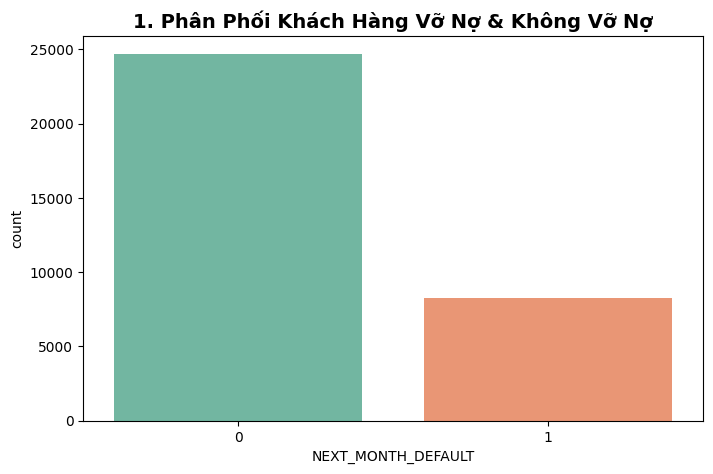

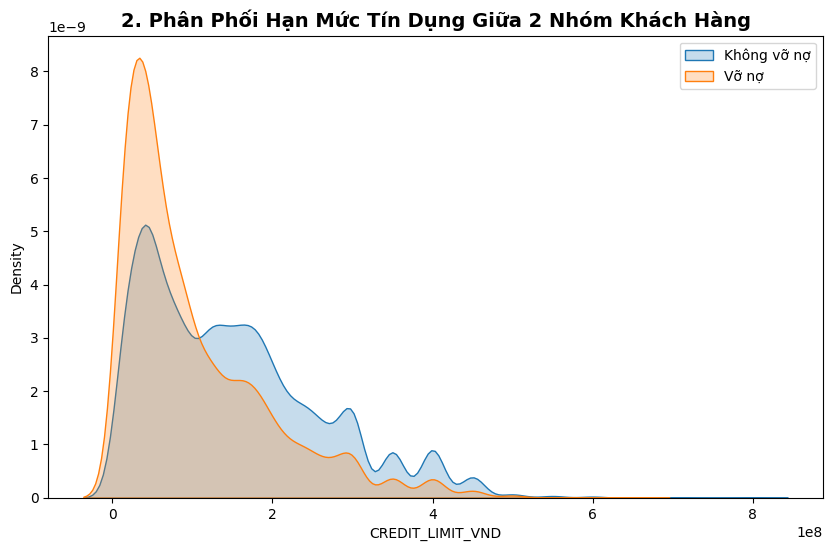

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='NEXT_MONTH_DEFAULT', palette='Set2')
plt.title('1. Phân Phối Khách Hàng Vỡ Nợ & Không Vỡ Nợ', fontsize=14, fontweight='bold')
plt.show()
plt.figure(figsize=(10, 6))
try:
    sns.histplot(data=df_clean, x='CREDIT_LIMIT_VND', hue='NEXT_MONTH_DEFAULT', 
                 bins=30, kde=True, palette='Set1', common_norm=False)
except ValueError:
    sns.kdeplot(data=df_clean[df_clean['NEXT_MONTH_DEFAULT']==0], x='CREDIT_LIMIT_VND', label='Không vỡ nợ', fill=True)
    sns.kdeplot(data=df_clean[df_clean['NEXT_MONTH_DEFAULT']==1], x='CREDIT_LIMIT_VND', label='Vỡ nợ', fill=True)
    plt.legend()
plt.title('2. Phân Phối Hạn Mức Tín Dụng Giữa 2 Nhóm Khách Hàng', fontsize=14, fontweight='bold')
plt.show()

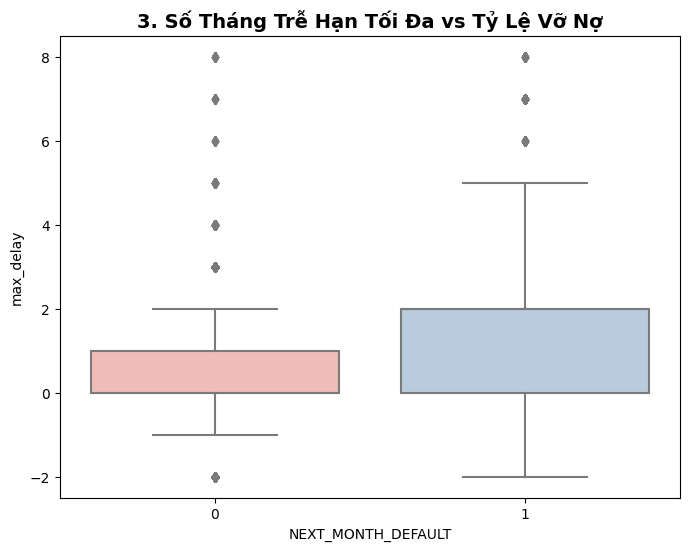

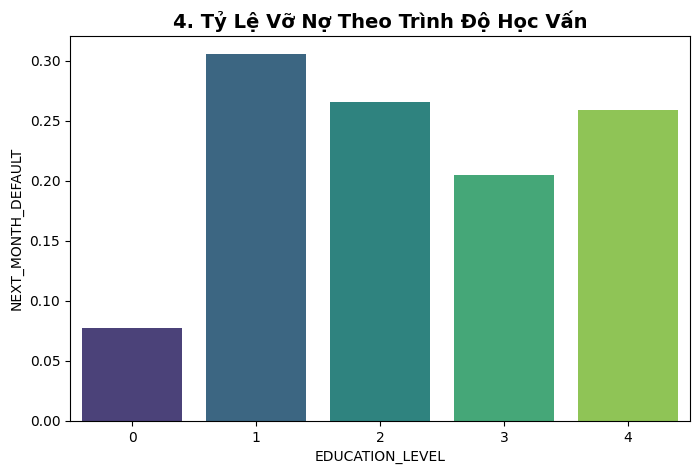

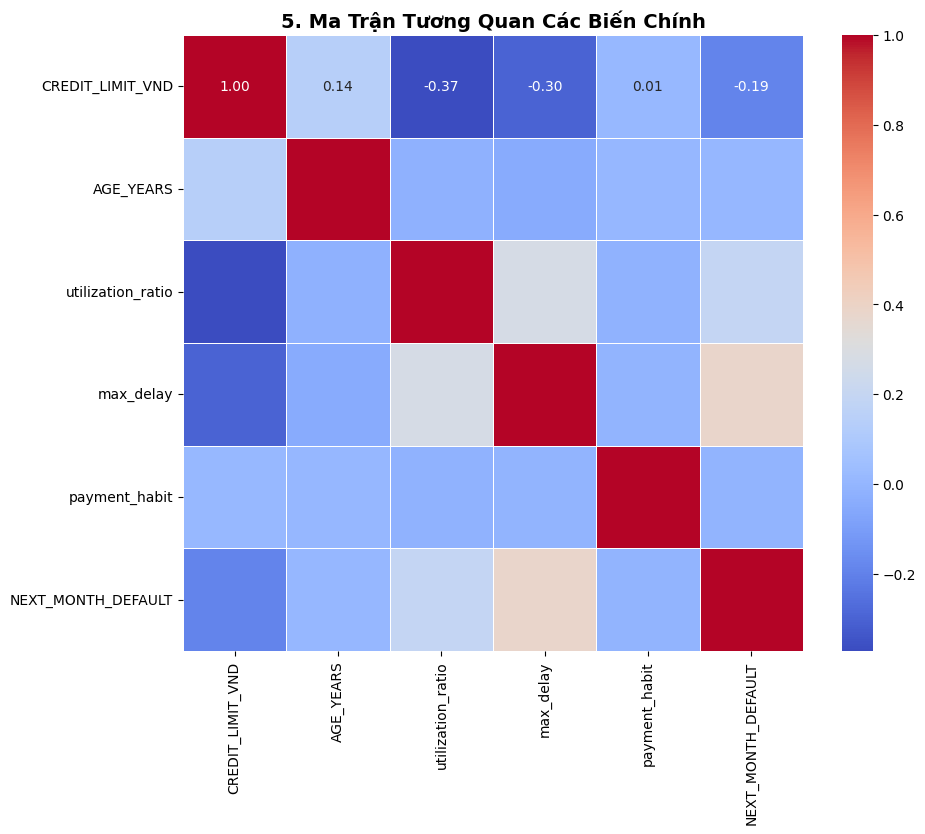

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='NEXT_MONTH_DEFAULT', y='max_delay', palette='Pastel1')
plt.title('3. Số Tháng Trễ Hạn Tối Đa vs Tỷ Lệ Vỡ Nợ', fontsize=14, fontweight='bold')
plt.show()
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='EDUCATION_LEVEL', y='NEXT_MONTH_DEFAULT', errorbar=None, palette='viridis')
plt.title('4. Tỷ Lệ Vỡ Nợ Theo Trình Độ Học Vấn', fontsize=14, fontweight='bold')
plt.show()
plt.figure(figsize=(10, 8))
corr_cols = ['CREDIT_LIMIT_VND', 'AGE_YEARS', 'utilization_ratio', 'max_delay', 'payment_habit', 'NEXT_MONTH_DEFAULT']
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('5. Ma Trận Tương Quan Các Biến Chính', fontsize=14, fontweight='bold')
plt.show()